In [1]:
# =====================================================
# Imports
# =====================================================

import os
import sys
import pickle
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import StatePreparation

In [2]:
# ============================================================
# Setup Project Path
# ============================================================

project_root = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..")
)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:", project_root)

Project Root: c:\Users\akash\OneDrive\Documents\Qclarvoyance resources\Quantum_Protein_Ligand_Docking


In [3]:
with open("../../outputs/project_data.pkl", "rb") as f:

    project_data = pickle.load(f)

In [4]:
amp_data = project_data.amplitude_vectors[1]

print(amp_data)

AmplitudeData(num_qubits=4, basis_states=['0100', '1100', '1111', '0001', '1010'], indices=[4, 12, 15, 1, 10], amplitude_vector=array([0.       , 0.4472136, 0.       , 0.       , 0.4472136, 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.4472136, 0.       ,
       0.4472136, 0.       , 0.       , 0.4472136]))


In [5]:
num_qubits = amp_data.num_qubits

qc = QuantumCircuit(num_qubits)
state_preparation = StatePreparation(amp_data.amplitude_vector)
qc.append(state_preparation,qc.qubits)

qc

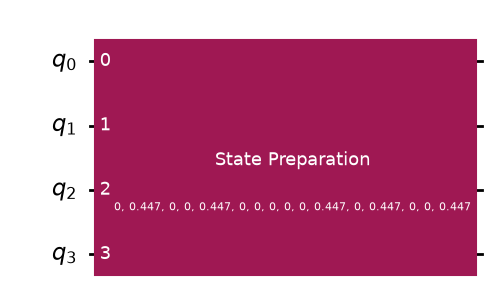

In [6]:
qc.draw("mpl")

In [7]:
prepared_state = Statevector.from_instruction(qc)

prepared_state

Statevector([-1.12971057e-16-1.07208805e-17j,
              4.47213595e-01-1.94289029e-16j,
              2.77555756e-17+6.70958312e-17j,
             -6.82211528e-33-2.81295766e-32j,
              4.47213595e-01-3.05311332e-16j,
             -1.33246693e-17-4.15235677e-17j,
             -2.77555756e-17+3.07956238e-17j,
              9.03517353e-33-6.09645363e-33j,
             -2.77555756e-17+9.99530918e-17j,
              1.20965207e-32-2.81135339e-32j,
              4.47213595e-01-5.55111512e-17j,
              3.76127960e-17-7.61396722e-17j,
              4.47213595e-01-2.77555756e-16j,
             -1.54546120e-16-1.37679921e-17j,
             -1.12971057e-16-3.73619156e-17j,
              4.47213595e-01-8.32667268e-17j],
            dims=(2, 2, 2, 2))


In [8]:
np.allclose(prepared_state.data,amp_data.amplitude_vector)

True

In [9]:
print("Prepared State\n")

for index, amplitude in enumerate(prepared_state.data):
    if abs(amplitude) > 1e-10:
        print(f"|{index:06b}>",amplitude)

Prepared State

|000001> (0.44721359549995726-1.942890293094024e-16j)
|000100> (0.44721359549995765-3.0531133177191805e-16j)
|001010> (0.4472135954999578-5.551115123125783e-17j)
|001100> (0.44721359549995715-2.7755575615628914e-16j)
|001111> (0.44721359549995726-8.326672684688674e-17j)


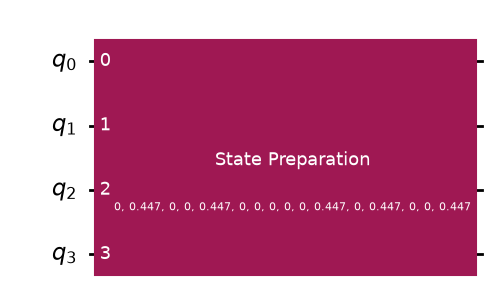

In [10]:
from src.quantum.state_preparation import StatePreparationBuilder

builder = StatePreparationBuilder()

qc = builder.prepare(project_data.amplitude_vectors[1])

qc.draw("mpl")

In [11]:
from qiskit.quantum_info import Statevector

prepared_state = Statevector.from_instruction(qc)

prepared_state

Statevector([-1.12971057e-16-1.07208805e-17j,
              4.47213595e-01-1.94289029e-16j,
              2.77555756e-17+6.70958312e-17j,
             -6.82211528e-33-2.81295766e-32j,
              4.47213595e-01-3.05311332e-16j,
             -1.33246693e-17-4.15235677e-17j,
             -2.77555756e-17+3.07956238e-17j,
              9.03517353e-33-6.09645363e-33j,
             -2.77555756e-17+9.99530918e-17j,
              1.20965207e-32-2.81135339e-32j,
              4.47213595e-01-5.55111512e-17j,
              3.76127960e-17-7.61396722e-17j,
              4.47213595e-01-2.77555756e-16j,
             -1.54546120e-16-1.37679921e-17j,
             -1.12971057e-16-3.73619156e-17j,
              4.47213595e-01-8.32667268e-17j],
            dims=(2, 2, 2, 2))


In [12]:
from qiskit.quantum_info import state_fidelity

state_fidelity(prepared_state,project_data.amplitude_vectors[1].amplitude_vector)

0.9999999999999976

In [13]:
# qc = builder.prepare(amp_data)

print(qc.depth())
print(qc.size())
print(qc.count_ops())

1
1
OrderedDict({'state_preparation': 1})
